# 🚀 Churn Prediction — Interrapidísimo
## Modelo de Regresión Logística para Predicción de Fuga de Clientes (churn)

**Autor:** Julián Echeverry  
**Rol:** Científico de Datos y Analítica  

---

### Contexto
Interrapidísimo cuenta con un dataset histórico de comportamiento de clientes con más de 10.000 registros. 
El objetivo es construir un modelo predictivo de **churn** robusto,  
siguiendo buenas prácticas de ingeniería y estándares de AWS.

### Estructura del notebook
1. Carga y verificación del dataset limpio  
2. Winsorización de outliers  
3. Feature Engineering  
4. Preprocesamiento con ColumnTransformer  
5. Split train/test estratificado  
6. Pipeline + GridSearchCV  
7. Evaluación del modelo  
8. Ajuste de umbral de decisión  
9. Métricas de impacto de negocio  
10. Análisis SHAP  
11. Guardado del pipeline del modelo en archivo reproducible (.pkl)


## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    make_scorer, recall_score, precision_score, f1_score
)

SEED = 42
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga del Dataset Limpio
El dataset proviene de la capa **cleaned/** (`1_data/2_cleaned`) del Data Lake.  
Ya fue procesado en la Fase 1: anonimizado, fechas normalizadas,  
nulos imputados y duplicados eliminados.

In [8]:
# Importar dataset preprocesado

INPUT_PATH = Path("../1_data/2_cleaned/05_cleaned_customers.csv")
df = pd.read_csv(INPUT_PATH, low_memory=False)

print(f"Dimensiones  : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Tasa de churn: {df['churn'].mean():.2%}")
df.head()

Dimensiones  : 10,000 filas x 14 columnas
Tasa de churn: 30.83%


,customer_id,antiguedad_dias,ciudad,tipo_cliente,canal_principal,tiene_contrato,num_envios_6m,valor_total_6m,ticket_promedio,dias_ultimo_envio,num_reclamos_6m,tasa_entrega_exitosa,nps_score,churn
0,eba190fb9ed9cc38,1273.0,Medellín,Natural,Web,0,6.0,83400.0,13900.0,31.0,0.0,0.8788,6.7,0
1,4ac66c326fa997c5,419.0,Cali,Empresa,API,1,16.0,785600.0,49100.0,94.0,1.0,0.9336,4.5,0
2,d82c91ffabf02a54,1592.0,Bogotá,Empresa,App,0,8.0,833600.0,52100.0,31.0,1.0,0.8486,7.3,0
3,90867e0226bd9f39,1273.0,Cali,Natural,Web,0,4.0,36288000.0,10300.0,40.0,4.0,0.8884,7.7,1
4,ec8f73f35fe3a31f,2065.0,Bogotá,Natural,Punto físico,1,5.0,172600.0,14000.0,31.0,2.0,0.8474,7.2,0


## Variables originales

| # | Variable | Tipo | Descripción | Valores posibles | ¿PII? | Tratamiento |
|---|---|---|---|---|---|---|
| 1 | `customer_id` | string | Identificador único del cliente | CLI000001... | ⚠️ Sí | Hasheado SHA-256 |
| 2 | `nombre` | string | Nombre completo del cliente | Texto libre | ⚠️ Sí | Eliminado |
| 3 | `email` | string | Correo electrónico | Texto libre | ⚠️ Sí | Eliminado |
| 4 | `telefono` | string | Teléfono de contacto | Texto libre | ⚠️ Sí | Eliminado |
| 5 | `fecha_registro` | string | Fecha de registro del cliente | YYYY-MM-DD (+ formatos corruptos) | No | Parseada multi-formato → NaT si inválida |
| 6 | `antiguedad_dias` | numérico | Días como cliente activo | 0 — 1825 | No | Imputado con mediana |
| 7 | `ciudad` | categórico | Ciudad de origen del cliente | Bogotá, Medellín, Cali... | No | Imputado con moda |
| 8 | `tipo_cliente` | categórico | Segmento del cliente | Natural, Empresa, Ecommerce | No | Imputado con moda |
| 9 | `canal_principal` | categórico | Canal de uso preferido | App, Web, Punto físico, API | No | Imputado con moda |
| 10 | `tiene_contrato` | binario | Si tiene contrato corporativo | 0, 1 | No | Sin imputación |
| 11 | `num_envios_6m` | numérico | Número de envíos últimos 6 meses | 0 — n | No | Imputado con mediana |
| 12 | `valor_total_6m` | numérico | Valor total facturado últimos 6 meses (COP) | 0 — 50.000.000 | No | Imputado con mediana + Winsorización p99 |
| 13 | `ticket_promedio` | numérico | Valor promedio por envío (COP) | 3.000 — n | No | Imputado con mediana |
| 14 | `dias_ultimo_envio` | numérico | Días desde el último envío (recencia) | 1 — 365 | No | Imputado con mediana |
| 15 | `num_reclamos_6m` | numérico | Número de reclamos últimos 6 meses | 0 — n | No | Imputado con mediana |
| 16 | `tasa_entrega_exitosa` | numérico | % de envíos entregados sin novedad | 0.50 — 1.00 | No | Imputado con mediana |
| 17 | `nps_score` | numérico | Net Promoter Score del cliente | 0 — 10 | No | Imputado con mediana |
| 18 | `churn` | binario | Variable objetivo — fuga del cliente | 0 = Activo, 1 = Churn | No | Target |

## 3. Winsorización de Outliers
Se detectaron **325 outliers extremos** en `valor_total_6m` durante el EDA.  

Remplazamos los valores extremos con los valores al **percentil 99** para evitar que distorsionen la distribución de los datos y, por consiguiente el modelo, sin necesidad de borrar filas enteras de información.

In [9]:
p99 = df["valor_total_6m"].quantile(0.99)
df["valor_total_6m"] = df["valor_total_6m"].clip(upper=p99)

print(f"Percentil 99           : {p99:,.0f} COP")
print(f"Valor máximo post-wins.: {df['valor_total_6m'].max():,.0f} COP")

Percentil 99           : 34,425,300 COP
Valor máximo post-wins.: 34,425,300 COP


## 4. Feature Engineering

### Variables creadas para el modelo

| Feature | Fórmula | Justificación |
|---|---|---|
| `ratio_reclamos_envios` | reclamos / (envíos + 1) | Normaliza reclamos por actividad |
| `segmento_recencia` | bins de `dias_ultimo_envio` | Captura ciclo de vida del cliente |

### Variables creadas y excluidas del modelo

| Feature | Razón de exclusión |
|---|---|
| `anio_registro` | Derivada de fechas NaT — excluida en capa cleaned/ dado el alcance del modelo|
| `mes_registro` | Derivada de fechas NaT — excluida en capa cleaned/ dado el alcance del modelo|
| `dia_semana` | Derivada de fechas NaT — excluida en capa cleaned/ dado el alcance del modelo|

In [10]:
df["ratio_reclamos_envios"] = df["num_reclamos_6m"] / (df["num_envios_6m"] + 1)

df["segmento_recencia"] = pd.cut(
    df["dias_ultimo_envio"],
    bins=[0, 15, 45, 90, 365],
    labels=["activo", "reciente", "en_riesgo", "inactivo"]
).astype(str)

print("Distribución segmento_recencia:")
print(df["segmento_recencia"].value_counts())

Distribución segmento_recencia:
segmento_recencia
reciente     3893
activo       2772
en_riesgo    2099
inactivo     1236
Name: count, dtype: int64


## 5. Definición de Features y Target

In [11]:
NUMERICAS = [
    "antiguedad_dias", "num_envios_6m", "valor_total_6m",
    "ticket_promedio", "dias_ultimo_envio", "num_reclamos_6m",
    "tasa_entrega_exitosa", "nps_score", "ratio_reclamos_envios"
]
CATEGORICAS = [
    "ciudad", "tipo_cliente", "canal_principal",
    "tiene_contrato", "segmento_recencia"
]

X = df[NUMERICAS + CATEGORICAS]
# Variable objetivo
y = df["churn"]

print(f"Features explicativas numéricas  : {len(NUMERICAS)}")
print(f"Features explicativas categóricas: {len(CATEGORICAS)}")
print(f"Total features      : {len(NUMERICAS + CATEGORICAS)}")

Features explicativas numéricas  : 9
Features explicativas categóricas: 5
Total features      : 14


## 6. Split Train/Test Estratificado (70/30)
Usamos `stratify=y` para garantizar que la proporción de churn  
sea igual en train y test, evitando ***sesgo por muestreo*** el cual puede afectar la capacidad del modelo para generalizar hacia datos no usados en el entrenamiento.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED, # semilla de aleatorización para reproducibilidad
    stratify=y
)

print(f"Train: {len(X_train):,} filas | churn={y_train.mean():.2%}")
print(f"Test : {len(X_test):,}  filas | churn={y_test.mean():.2%}")

Train: 7,000 filas | churn=30.83%
Test : 3,000  filas | churn=30.83%


## 7. Pipeline: ColumnTransformer + GridSearchCV
Construimos un pipeline con instrucciones de transformación de variables, en que se incluye:

- **ColumnTransformer**: aplica One Hot Encoding a variables categóricas y StandardScaler a variables numéricas, transformaciones estándar en este tipo de modelos.
- **Pipeline**: encadena preprocesamiento + modelo en un único objeto serializable  
- **GridSearchCV**: 5-fold CV optimizando **Recall de la clase Churn (pos_label=1)**. Optimizamos los hiperparámetros : `C` (El modelo prefiere un margen más amplio, incluso si comete algunos errores en el entrenamiento.) y `l1_ratio` (Tiende a reducir los coeficientes de las variables menos importantes exactamente a cero), y de esta manera controlamos que el modelo no tenga sobreajuste.

> **Decisión de scoring:** el costo de un falso negativo (churner no detectado) supera el costo de un falso positivo (intervención innecesaria). Se optimiza la métrica del Recall, ya que, en el caso de negocio presentado ***es más grave aumentar el número de falsos negativos (clientes que sí podrían fugarse pero que no detecta el modelo)*** dadas las consecuencias para los ingresos de la compañía.

In [13]:
preprocesamiento = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), CATEGORICAS),
    ("num", StandardScaler(), NUMERICAS),
])

pipeline = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", GridSearchCV(
        estimator=LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=1000,
            random_state=SEED
        ),
        param_grid={
            "C"       : [0.01, 0.1, 1, 10, 100],
            "l1_ratio": [0.0, 0.5, 1.0],
        },
        scoring=make_scorer(recall_score, pos_label=1),
        cv=5,
        n_jobs=-1,
        verbose=1,
    ))
])

print("⏳ Entrenando pipeline — puede tardar varios minutos...")
pipeline.fit(X_train, y_train)

best_params = pipeline.named_steps["modelo"].best_params_
best_score  = pipeline.named_steps["modelo"].best_score_
print(f"\n✅ Entrenamiento completado")
print(f"Mejores parámetros : {best_params}")
print(f"Recall CV (train)  : {best_score:.4f}")

⏳ Entrenando pipeline — puede tardar varios minutos...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\interrapidisimo-churn-APYZ3-2T-py3.11\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



✅ Entrenamiento completado
Mejores parámetros : {'C': 1, 'l1_ratio': 1.0}
Recall CV (train)  : 0.4546


## 8. Evaluación del Modelo (umbral=0.5)

In [14]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC: {auc:.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Activo","Churn"]))

AUC-ROC: 0.7750

Matriz de confusión:
[[1882  193]
 [ 541  384]]

Classification Report:
              precision    recall  f1-score   support

      Activo       0.78      0.91      0.84      2075
       Churn       0.67      0.42      0.51       925

    accuracy                           0.76      3000
   macro avg       0.72      0.66      0.67      3000
weighted avg       0.74      0.76      0.74      3000



## 9. Ajuste de Umbral de Decisión
Con `threshold=0.50` el Recall de Churn es bajo (~0.42). En la práctica, esto significa que el modelo tiene un bajo nivel predictivo para la categoría positiva (`Churn`).

Por esa razón, exploramos umbrales entre 0.20 y 0.60 para maximizar el Recall manteniendo un F1 razonable.

> **Nota:** Esta situación está fuertemente influenciada por el tamaño del conjunto de datos (~ 10.000 registros). Una muestra mayor podría arrojar como resultado un modelo con un desempeño sustancialmente diferente, en respuesta a otra distribución de las variables objetivo y explicativas.

In [15]:
umbrales   = np.arange(0.20, 0.60, 0.02)
resultados = []
for t in umbrales:
    y_pred_t = (y_prob >= t).astype(int)
    resultados.append({
        "umbral"   : round(t, 2),
        "recall"   : recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "f1"       : f1_score(y_test, y_pred_t),
    })

df_umbrales   = pd.DataFrame(resultados).set_index("umbral")
candidatos    = df_umbrales[df_umbrales["recall"] >= 0.70]
UMBRAL_OPTIMO = candidatos["f1"].idxmax() if len(candidatos) > 0 else df_umbrales["recall"].idxmax()
y_pred        = (y_prob >= UMBRAL_OPTIMO).astype(int)

print(f"Umbral óptimo: {UMBRAL_OPTIMO}")
print(f"\nMétricas con umbral={UMBRAL_OPTIMO}:")
print(classification_report(y_test, y_pred, target_names=["Activo","Churn"]))
df_umbrales

Umbral óptimo: 0.28

Métricas con umbral=0.28:
              precision    recall  f1-score   support

      Activo       0.84      0.66      0.74      2075
       Churn       0.49      0.73      0.58       925

    accuracy                           0.68      3000
   macro avg       0.67      0.69      0.66      3000
weighted avg       0.73      0.68      0.69      3000



,recall,precision,f1
umbral,,,
0.20,0.844324,0.436557,0.575534
0.22,0.809730,0.447699,0.576597
0.24,0.781622,0.462276,0.580956
0.26,0.756757,0.475867,0.584307
0.28,0.727568,0.488389,0.584455
0.30,0.700541,0.499230,0.582996
0.32,0.669189,0.508210,0.577695
0.34,0.651892,0.528484,0.583737
0.36,0.628108,0.554389,0.588951


## 10. Visualizaciones de Evaluación

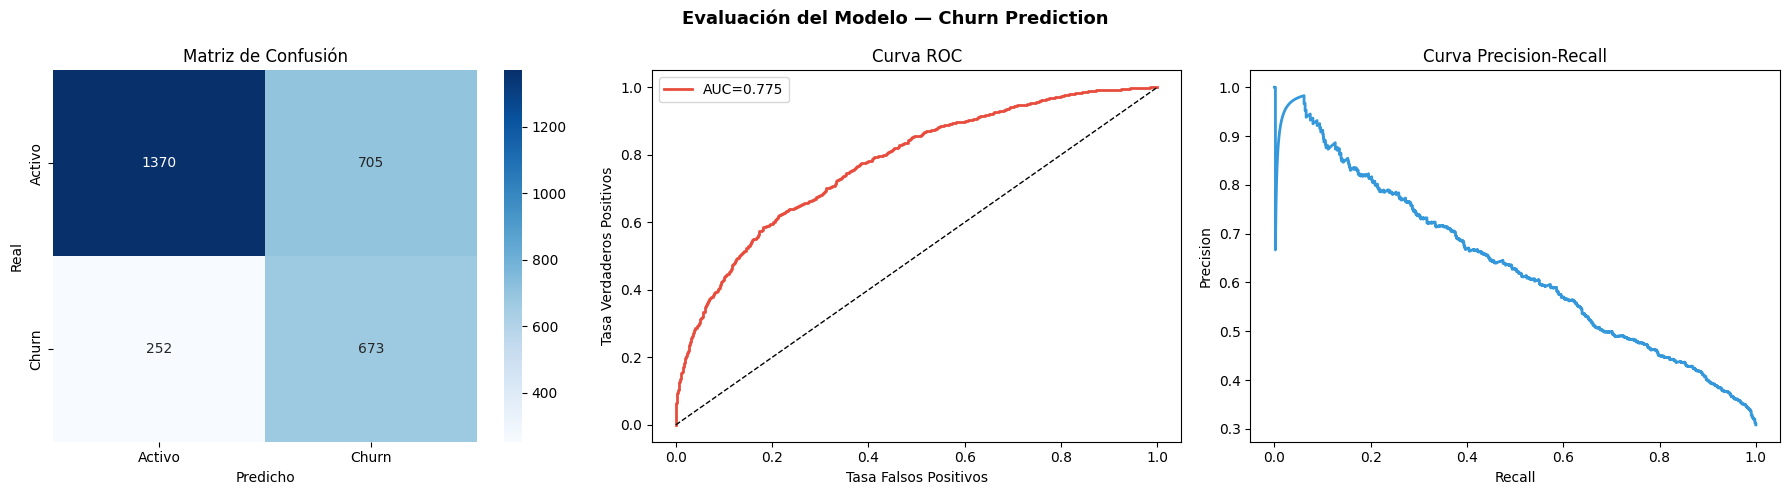

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Evaluación del Modelo — Churn Prediction", fontsize=13, fontweight="bold")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Activo","Churn"], yticklabels=["Activo","Churn"], ax=axes[0])
axes[0].set_title("Matriz de Confusión")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC={auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("Tasa Falsos Positivos")
axes[1].set_ylabel("Tasa Verdaderos Positivos")
axes[1].legend()

precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall_arr, precision_arr, color="#3498db", lw=2)
axes[2].set_title("Curva Precision-Recall")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## 11. Métricas de Impacto de Negocio
> ⚠️ Los siguientes valores son **supuestos estimados**.  
> Deben ser validados con las áreas comercial y financiera de Interrapidísimo.

In [17]:
SUPUESTOS = {
    "LTV_PROMEDIO"       : df["valor_total_6m"].median() * 2,
    "COSTO_INTERVENCION" : 15_000,
    "TASA_RETENCION"     : 0.30,
}

cm             = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

clientes_contactados = tp + fp
clientes_retenidos   = int(clientes_contactados * SUPUESTOS["TASA_RETENCION"])
costo_total          = clientes_contactados * SUPUESTOS["COSTO_INTERVENCION"]
ingreso_retenido     = clientes_retenidos   * SUPUESTOS["LTV_PROMEDIO"]
roi                  = (ingreso_retenido - costo_total) / costo_total * 100

print(f"Supuestos de negocio:")
for k, v in SUPUESTOS.items():
    print(f"  {k:25s}: {v:,.2f}")

print(f"\nMétricas de impacto:")
print(f"  Clientes churn detectados (TP): {tp:,}")
print(f"  Falsos positivos (FP)          : {fp:,}")
print(f"  Clientes a contactar           : {clientes_contactados:,}")
print(f"  Clientes retenidos estimados   : {clientes_retenidos:,}")
print(f"  Costo total campaña            : ${costo_total:,.0f} COP")
print(f"  Ingreso retenido estimado      : ${ingreso_retenido:,.0f} COP")
print(f"  ROI estimado del modelo        : {roi:.1f}%")

Supuestos de negocio:
  LTV_PROMEDIO             : 345,200.00
  COSTO_INTERVENCION       : 15,000.00
  TASA_RETENCION           : 0.30

Métricas de impacto:
  Clientes churn detectados (TP): 673
  Falsos positivos (FP)          : 705
  Clientes a contactar           : 1,378
  Clientes retenidos estimados   : 413
  Costo total campaña            : $20,670,000 COP
  Ingreso retenido estimado      : $142,567,600 COP
  ROI estimado del modelo        : 589.7%


## 12. Análisis SHAP — Explicabilidad del Modelo
SHAP (SHapley Additive exPlanations) permite entender **qué variables impulsan la predicción de churn**.

- **mean|SHAP| alto** → variable muy influyente globalmente  
- **SHAP positivo** → aumenta probabilidad de churn  
- **SHAP negativo** → disminuye probabilidad de churn

In [18]:
preprocesador  = pipeline.named_steps["preprocesamiento"]
mejor_modelo   = pipeline.named_steps["modelo"].best_estimator_
X_transformado = preprocesador.transform(X)

ohe_features  = preprocesador.named_transformers_["cat"]    .get_feature_names_out(CATEGORICAS).tolist()
feature_names = ohe_features + NUMERICAS

np.random.seed(SEED)
idx_muestra   = np.random.choice(len(X_transformado), size=1000, replace=False)
X_muestra     = X_transformado[idx_muestra]

explainer   = shap.LinearExplainer(mejor_modelo, X_muestra)
shap_values = explainer.shap_values(X_muestra)

importancia = pd.DataFrame({
    "feature"  : feature_names,
    "mean_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_shap", ascending=False).reset_index(drop=True)

print("Top 10 variables más influyentes:")
importancia.head(10)

Top 10 variables más influyentes:


,feature,mean_shap
0,num_reclamos_6m,0.568665
1,nps_score,0.441671
2,num_envios_6m,0.427603
3,dias_ultimo_envio,0.420717
4,tasa_entrega_exitosa,0.335183
5,tiene_contrato_1,0.271640
6,tipo_cliente_Natural,0.098337
7,canal_principal_App,0.085356
8,canal_principal_Web,0.061440
9,tipo_cliente_Empresa,0.049203


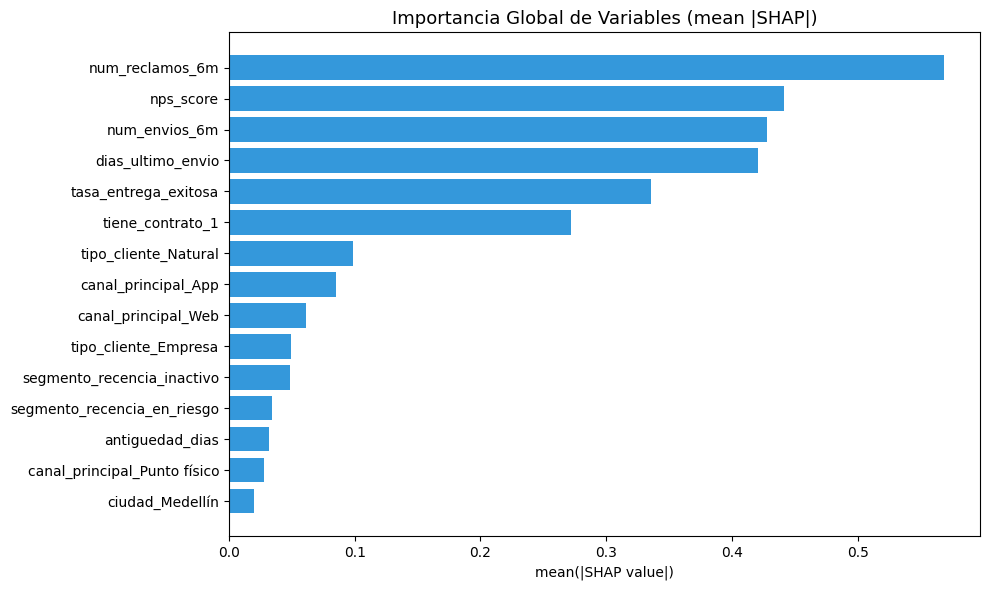

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
top15 = importancia.head(15)
ax.barh(top15["feature"][::-1], top15["mean_shap"][::-1], color="#3498db")
ax.set_title("Importancia Global de Variables (mean |SHAP|)", fontsize=13)
ax.set_xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

**── Top 15 variables por importancia SHAP ──────────────────**

|ID|feature|mean_shap|
|---|---|---|
|0|num_reclamos_6m|0.568656|
|1|nps_score|0.441735|
|2|num_envios_6m|0.427061|
|3|dias_ultimo_envio|0.421765|
|4|tasa_entrega_exitosa|0.335237|
|5|tiene_contrato_1|0.271777|
|6|tipo_cliente_Natural|0.099405|
|7|canal_principal_App|0.086689|
|8|canal_principal_Web|0.062561|
|9|tipo_cliente_Empresa|0.050353|
|10|segmento_recencia_inactivo|0.049523|
|11|segmento_recencia_en_riesgo|0.034924|
|12|antiguedad_dias|0.032120|
|13|canal_principal_Punto físico|0.029333|
|14|ciudad_Medellín|0.020455|

### Variables más influyentes (SHAP)

1. `num_reclamos_6m` — Los reclamos son el predictor más fuerte de churn
2. `nps_score` — La satisfacción del cliente es clave para la retención
3. `num_envios_6m` — La actividad reciente refleja el compromiso del cliente

### Recomendaciones para el Negocio

1. Realizar estudios de mercado para detectar los principales drivers del número de reclamos y del nps_score.
2. Aplicar modelos de lenguaje natural a las quejas registradas para detectar los principales drivers del número de reclamos y del nps_score.
3. Materializar en base de datos el seguimiento a las características del servicio prestado por los competidores (servientrega, Coordinadora, Envía, Velotax, Envíos Verdes, Omega, Uber, Didi, entre otros). Esto con miras a fortalecer la oferta de Interrapidísimo hacia cada segmento de clientes (envío ocasional de persona natural, envíos del segmento e-commerce, envíos de fabricantes de mercancías, etc).

## 13. Guardado del Pipeline
Guardamos el pipeline completo (preprocesamiento + modelo) en `.pkl`  
usando `joblib`. Permite deployment directo en SageMaker Endpoint.

In [20]:
MODEL_PATH = Path("../1_data/3_features/pipeline.pkl")
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Pipeline guardado en: {MODEL_PATH}")

modelo_cargado = joblib.load(MODEL_PATH)
muestra_pred   = modelo_cargado.predict(X_test.iloc[:5])
print(f"Verificación predict() desde .pkl: {muestra_pred}")

✅ Pipeline guardado en: ..\1_data\3_features\pipeline.pkl
Verificación predict() desde .pkl: [0 0 0 1 0]


## 14. Conclusiones

### Decisiones técnicas clave
- **Umbral 0.28**: prioriza Recall sobre Precision — el costo de no detectar un churner supera el de intervenir innecesariamente
- **Winsorización p99**: trata outliers sin pérdida de filas
- **ElasticNet**: regularización flexible que combina L1 y L2
- **Pipeline serializable**: permite deployment directo en SageMaker Endpoint

### Resultados del modelo
| Métrica | Valor |
|---|---|
| AUC-ROC | 0.7749 |
| Recall Churn (umbral=0.28) | 0.73 |
| Precision Churn | 0.49 |
| F1 Churn | 0.58 |

### Variables más influyentes (SHAP)
1. `num_reclamos_6m` — Los reclamos son el predictor más fuerte de churn
2. `nps_score` — La satisfacción del cliente es clave para la retención
3. `num_envios_6m` — La actividad reciente refleja el compromiso del cliente

### Recomendaciones para el Negocio

1. Realizar estudios de mercado para detectar los principales drivers del número de reclamos y del nps_score.
2. Aplicar modelos de lenguaje natural a las quejas registradas para detectar los principales drivers del número de reclamos y del nps_score.
3. Materializar en base de datos el seguimiento a las características del servicio prestado por los competidores (servientrega, Coordinadora, Envía, Velotax, Envíos Verdes, Omega, Uber, Didi, entre otros). Esto con miras a fortalecer la oferta de Interrapidísimo hacia cada segmento de clientes (envío ocasional de persona natural, envíos del segmento e-commerce, envíos de fabricantes de mercancías, etc), mejorando el número de envíos.
